Импорты, seed и устройство

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import json
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


Загрузка датасета EMNIST и определение transform

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


dataset_train = datasets.EMNIST(root='./data',
                          train=True,
                          download=True,
                          transform=transforms.ToTensor(),
                          split="balanced")
dataset_test = datasets.EMNIST(root='./data',
                          train=False,
                          download=True,
                          transform=transforms.ToTensor(),
                          split="balanced")

Разбиение train/val из train-части с фиксированным seed

In [5]:
train_ratio = 0.8
train_size = int(train_ratio * len(dataset_train))
val_size = len(dataset_train) - train_size

generator = torch.Generator().manual_seed(SEED)
dataset_train, dataset_val = random_split(
    dataset_train,
    [train_size, val_size],
    generator=generator
)

Создать DataLoader для train/val/test

In [6]:
batch_size = 64

train_loader = DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    dataset_val,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [7]:
x_batch, y_batch = next(iter(train_loader))

print(f"Количество батчей: {len(train_loader)}")
print(f"Размер батча: {x_batch.shape[0]}")
print(f"Shape images: {x_batch.shape}")
print(f"Shape labels: {y_batch.shape}")
print(f"Тип данных images: {x_batch.dtype}")
print(f"Тип данных labels: {y_batch.dtype}")
print(f"Уникальные метки в батче: {torch.unique(y_batch).tolist()}")
print(f"images min value: {x_batch.min():.4f}")
print(f"images max value: {x_batch.max():.4f}")
print(f"images mean value: {x_batch.mean():.4f}")
print(f"images std value: {x_batch.std():.4f}")

Количество батчей: 1410
Размер батча: 64
Shape images: torch.Size([64, 1, 28, 28])
Shape labels: torch.Size([64])
Тип данных images: torch.float32
Тип данных labels: torch.int64
Уникальные метки в батче: [0, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 19, 23, 24, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 46]
images min value: 0.0000
images max value: 1.0000
images mean value: 0.1919
images std value: 0.3483


Класс MLP

In [8]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_sizes=[512, 256], num_classes=47, dropout_rate=0.2, use_batchnorm=False):
        super(MLP, self).__init__()

        layers = []

        layers.append(nn.Flatten())

        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x)

    def get_features(self, x):
        for layer in self.network[:-1]:
            x = layer(x)
        return x

input_size = 28 * 28
num_classes = 47
model = MLP(
    input_size=input_size,
    hidden_sizes=[512, 256, 128],
    num_classes=num_classes,
    dropout_rate=0.2
).to(device)


Реализованные функции evaluate, model.eval и torch.no_grad

In [9]:
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0
    total_batches = len(train_loader)

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)

        if (batch_idx + 1) % 200 == 0:
            print(f'  Batch [{batch_idx+1}/{total_batches}], '
                  f'Loss: {loss.item():.4f}, '
                  f'Acc: {calculate_accuracy(outputs, labels):.4f}')

    epoch_loss = running_loss / total_batches
    epoch_accuracy = running_accuracy / total_batches

    return epoch_loss, epoch_accuracy

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_accuracy = 0.0
    total_batches = len(val_loader)

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_accuracy += calculate_accuracy(outputs, labels)

    avg_loss = running_loss / total_batches
    avg_accuracy = running_accuracy / total_batches

    return avg_loss, avg_accuracy

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

print(f"Начало обучения на устройстве: {device}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("=" * 70)

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print("-" * 70)

    # Обучение
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Валидация
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    # Сохранение истории
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

Начало обучения на устройстве: cpu
Train batches: 1410, Val batches: 353

Epoch [1/10]
----------------------------------------------------------------------
  Batch [200/1410], Loss: 1.4592, Acc: 0.5625
  Batch [400/1410], Loss: 1.2612, Acc: 0.5781
  Batch [600/1410], Loss: 1.1076, Acc: 0.6250
  Batch [800/1410], Loss: 0.8846, Acc: 0.6875
  Batch [1000/1410], Loss: 0.7959, Acc: 0.7031
  Batch [1200/1410], Loss: 0.7469, Acc: 0.7500
  Batch [1400/1410], Loss: 0.9616, Acc: 0.6875

Train Loss: 1.2053, Train Acc: 0.6383
Val Loss:   0.6628, Val Acc:   0.7842

Epoch [2/10]
----------------------------------------------------------------------
  Batch [200/1410], Loss: 0.8535, Acc: 0.7031
  Batch [400/1410], Loss: 0.8513, Acc: 0.7500
  Batch [600/1410], Loss: 0.6149, Acc: 0.8438
  Batch [800/1410], Loss: 0.8399, Acc: 0.7031
  Batch [1000/1410], Loss: 0.6098, Acc: 0.8125
  Batch [1200/1410], Loss: 0.7627, Acc: 0.7969
  Batch [1400/1410], Loss: 0.6510, Acc: 0.6719

Train Loss: 0.7150, Train Acc

In [11]:
import time


def make_optimizer(model, kind="adam", lr=1e-3, weight_decay=0.0):
    """Создание оптимизатора"""
    kind = kind.lower()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {kind}")


class EarlyStopping:
    """Ранняя остановка"""
    def __init__(self, patience=5):
        self.patience = patience
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=10,
        early_stopping=None, verbose=True):
    """Полный цикл обучения"""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Обучение
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        # Валидация
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        dt = time.time() - t0

        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                  f"val loss {val_loss:.4f}, acc {val_acc:.3f} | {dt:.1f}s")

        # Early stopping
        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc, model)
            if should_stop:
                if verbose:
                    print(f"EarlyStopping: остановка на эпохе {epoch} "
                          f"Лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break

    return history

EPOCHS=10

E1 (base)

In [12]:
e1_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.0).to(device)
e1_opt = make_optimizer(e1_model, kind="adam", lr=1e-3, weight_decay=0.0)
e1_hist = fit(e1_model, train_loader, val_loader, e1_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 1.2190, Acc: 0.6719
  Batch [400/1410], Loss: 1.1216, Acc: 0.6250
  Batch [600/1410], Loss: 0.5717, Acc: 0.8125
  Batch [800/1410], Loss: 0.8249, Acc: 0.7500
  Batch [1000/1410], Loss: 0.8203, Acc: 0.7812
  Batch [1200/1410], Loss: 0.7360, Acc: 0.7500
  Batch [1400/1410], Loss: 0.4911, Acc: 0.8125
Epoch 01/10 | train loss 0.9272, acc 0.718 | val loss 0.6162, acc 0.797 | 27.8s
  Batch [200/1410], Loss: 0.6095, Acc: 0.8281
  Batch [400/1410], Loss: 0.5087, Acc: 0.8594
  Batch [600/1410], Loss: 0.4602, Acc: 0.8750
  Batch [800/1410], Loss: 0.5530, Acc: 0.7969
  Batch [1000/1410], Loss: 0.4627, Acc: 0.8281
  Batch [1200/1410], Loss: 0.4603, Acc: 0.8594
  Batch [1400/1410], Loss: 0.5324, Acc: 0.8125
Epoch 02/10 | train loss 0.5317, acc 0.820 | val loss 0.5106, acc 0.829 | 23.3s
  Batch [200/1410], Loss: 0.4114, Acc: 0.8906
  Batch [400/1410], Loss: 0.4683, Acc: 0.8594
  Batch [600/1410], Loss: 0.5303, Acc: 0.8125
  Batch [800/1410], Loss: 0.4856, Acc: 0.8125
  Batc

E2 (Dropout)

In [13]:
e2_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.3).to(device)
e2_opt = make_optimizer(e2_model, kind="adam", lr=1e-3, weight_decay=0.0)
e2_hist = fit(e2_model, train_loader, val_loader, e2_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 1.9193, Acc: 0.4844
  Batch [400/1410], Loss: 1.7104, Acc: 0.4375
  Batch [600/1410], Loss: 1.2483, Acc: 0.6562
  Batch [800/1410], Loss: 1.0460, Acc: 0.7031
  Batch [1000/1410], Loss: 1.2602, Acc: 0.6719
  Batch [1200/1410], Loss: 1.0284, Acc: 0.5938
  Batch [1400/1410], Loss: 0.8754, Acc: 0.7344
Epoch 01/10 | train loss 1.4027, acc 0.591 | val loss 0.6907, acc 0.779 | 24.0s
  Batch [200/1410], Loss: 1.2543, Acc: 0.6562
  Batch [400/1410], Loss: 0.8583, Acc: 0.7656
  Batch [600/1410], Loss: 0.6394, Acc: 0.7812
  Batch [800/1410], Loss: 0.9991, Acc: 0.7188
  Batch [1000/1410], Loss: 0.6511, Acc: 0.8125
  Batch [1200/1410], Loss: 0.9264, Acc: 0.7031
  Batch [1400/1410], Loss: 0.8530, Acc: 0.7812
Epoch 02/10 | train loss 0.8402, acc 0.735 | val loss 0.5904, acc 0.807 | 23.6s
  Batch [200/1410], Loss: 0.9395, Acc: 0.7656
  Batch [400/1410], Loss: 0.5861, Acc: 0.8594
  Batch [600/1410], Loss: 0.8080, Acc: 0.7812
  Batch [800/1410], Loss: 0.8592, Acc: 0.7656
  Batc

E3 (BatchNorm)

In [14]:
e3_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
               num_classes=47, dropout_rate=0.0, use_batchnorm=True).to(device)
e3_opt = make_optimizer(e3_model, kind="adam", lr=1e-3, weight_decay=0.0)
e3_hist = fit(e3_model, train_loader, val_loader, e3_opt, criterion, epochs=EPOCHS)

  Batch [200/1410], Loss: 0.9718, Acc: 0.6875
  Batch [400/1410], Loss: 0.7749, Acc: 0.7500
  Batch [600/1410], Loss: 0.8571, Acc: 0.7344
  Batch [800/1410], Loss: 0.9756, Acc: 0.6875
  Batch [1000/1410], Loss: 0.6707, Acc: 0.7500
  Batch [1200/1410], Loss: 0.3487, Acc: 0.8750
  Batch [1400/1410], Loss: 0.5756, Acc: 0.8125
Epoch 01/10 | train loss 0.9227, acc 0.719 | val loss 0.6511, acc 0.791 | 22.7s
  Batch [200/1410], Loss: 0.7645, Acc: 0.7344
  Batch [400/1410], Loss: 0.4912, Acc: 0.8125
  Batch [600/1410], Loss: 0.6002, Acc: 0.8125
  Batch [800/1410], Loss: 0.6058, Acc: 0.7969
  Batch [1000/1410], Loss: 0.4787, Acc: 0.8281
  Batch [1200/1410], Loss: 0.5969, Acc: 0.7969
  Batch [1400/1410], Loss: 0.5397, Acc: 0.8281
Epoch 02/10 | train loss 0.5328, acc 0.819 | val loss 0.5199, acc 0.824 | 26.0s
  Batch [200/1410], Loss: 0.2922, Acc: 0.9062
  Batch [400/1410], Loss: 0.4389, Acc: 0.8125
  Batch [600/1410], Loss: 0.7004, Acc: 0.7656
  Batch [800/1410], Loss: 0.3676, Acc: 0.8281
  Batc

E4 (EarlyStopping)

In [15]:
e2_best = max(e2_hist['val_acc'])
e3_best = max(e3_hist['val_acc'])


if e2_best >= e3_best:
    print("Выбираем Dropout")
    e4_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
                   num_classes=47, dropout_rate=0.3).to(device)
else:
    print("Выбираем Base")
    e4_model = MLP(input_size=28*28, hidden_sizes=[512, 256, 128],
                   num_classes=47, dropout_rate=0.0, use_batchnorm=True).to(device)

e4_opt = make_optimizer(e4_model, kind="adam", lr=1e-3, weight_decay=0.0)
early_stopper = EarlyStopping(patience=5)
e4_hist = fit(e4_model, train_loader, val_loader, e4_opt, criterion,
              epochs=EPOCHS, early_stopping=early_stopper)

Выбираем Base
  Batch [200/1410], Loss: 1.2396, Acc: 0.5938
  Batch [400/1410], Loss: 0.9025, Acc: 0.7500
  Batch [600/1410], Loss: 0.9237, Acc: 0.7344
  Batch [800/1410], Loss: 0.8193, Acc: 0.7500
  Batch [1000/1410], Loss: 0.5423, Acc: 0.8281
  Batch [1200/1410], Loss: 0.5025, Acc: 0.8125
  Batch [1400/1410], Loss: 0.4438, Acc: 0.7969
Epoch 01/10 | train loss 0.9255, acc 0.719 | val loss 0.6385, acc 0.795 | 23.4s
  Batch [200/1410], Loss: 0.6271, Acc: 0.8438
  Batch [400/1410], Loss: 0.4839, Acc: 0.7969
  Batch [600/1410], Loss: 0.4872, Acc: 0.8281
  Batch [800/1410], Loss: 0.3285, Acc: 0.8906
  Batch [1000/1410], Loss: 0.5102, Acc: 0.7969
  Batch [1200/1410], Loss: 0.6644, Acc: 0.7656
  Batch [1400/1410], Loss: 0.3616, Acc: 0.8906
Epoch 02/10 | train loss 0.5350, acc 0.819 | val loss 0.5373, acc 0.818 | 26.7s
  Batch [200/1410], Loss: 0.4941, Acc: 0.8438
  Batch [400/1410], Loss: 0.4279, Acc: 0.8750
  Batch [600/1410], Loss: 0.4075, Acc: 0.8438
  Batch [800/1410], Loss: 0.2761, Acc:

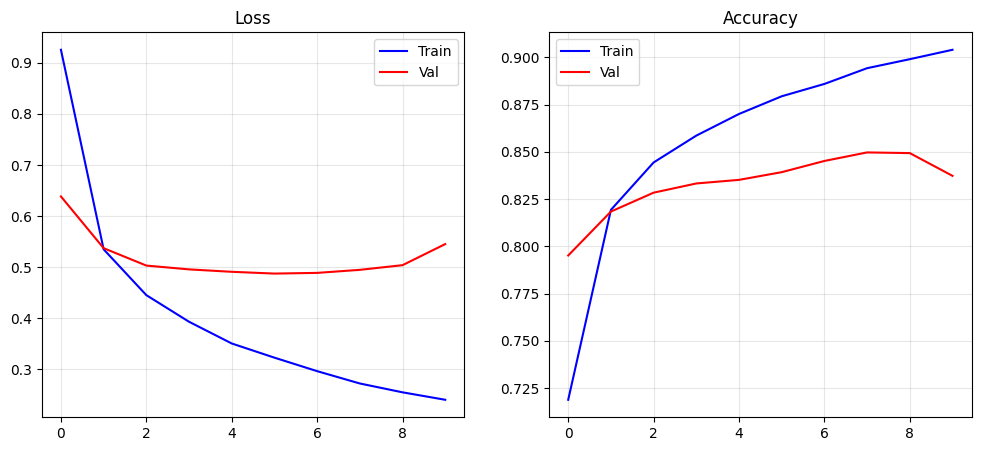

In [16]:
current_dir = os.getcwd()

artifacts_path = os.path.join(current_dir, 'artifacts', 'figures')
os.makedirs(artifacts_path, exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(e4_hist['train_loss'], 'b-', label='Train')
ax1.plot(e4_hist['val_loss'], 'r-', label='Val')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(e4_hist['train_acc'], 'b-', label='Train')
ax2.plot(e4_hist['val_acc'], 'r-', label='Val')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

file_path = os.path.join(artifacts_path, 'curves_best.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()


In [17]:
best_model = MLP(
    input_size=28*28,
    hidden_sizes=[512, 256, 128],
    num_classes=47,
    dropout_rate=0.0 
).to(device)

torch.save(e4_model.state_dict(), os.path.join("artifacts", "best_model.pt"))
best_model.eval()

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

In [18]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

results = {
    "E1 (Base)": {
        "val_acc": max(e1_hist['val_acc']),
        "val_loss": min(e1_hist['val_loss']),
        "epochs": len(e1_hist['val_acc'])
    },
    "E2 (Dropout p=0.3)": {
        "val_acc": max(e2_hist['val_acc']),
        "val_loss": min(e2_hist['val_loss']),
        "epochs": len(e2_hist['val_acc'])
    },
    "E3 (Base)": {
        "val_acc": max(e3_hist['val_acc']),
        "val_loss": min(e3_hist['val_loss']),
        "epochs": len(e3_hist['val_acc'])
    },
    "E4 (EarlyStopping)": {
        "val_acc": early_stopper.best_score,
        "val_loss": min(e4_hist['val_loss']),
        "epochs": len(e4_hist['val_acc'])
    }
}

final_results = pd.DataFrame({
    'Experiment': ['E1 (Base)', 'E2 (Dropout)', 'E3 (Base)', 'E4 (EarlyStopping)', 'Test (Final)'],
    'Val/Test Acc': [
        results['E1 (Base)']['val_acc'],
        results['E2 (Dropout p=0.3)']['val_acc'],
        results['E3 (Base)']['val_acc'],
        results['E4 (EarlyStopping)']['val_acc'],
        test_acc
    ],
    'Val/Test Loss': [
        results['E1 (Base)']['val_loss'],
        results['E2 (Dropout p=0.3)']['val_loss'],
        results['E3 (Base)']['val_loss'],
        results['E4 (EarlyStopping)']['val_loss'],
        test_loss
    ]
})
display(final_results)

,Experiment,Val/Test Acc,Val/Test Loss
0,E1 (Base),0.843750,0.477946
1,E2 (Dropout),0.840961,0.464711
2,E3 (Base),0.843263,0.492587
3,E4 (EarlyStopping),0.849681,0.487567
4,Test (Final),0.023420,3.872613


In [19]:
os.makedirs('artifacts', exist_ok=True)

# Конфигурация лучшей модели (E4)
best_config = {
    "dataset": "EMNIST balanced",
    "seed": SEED,
    "input_dim": 28 * 28,
    "hidden_dims": [512, 256, 128],
    "num_classes": 47,
    "activation": "relu",
    "dropout_rate": 0.0,
    "use_batchnorm": False,
    "optimizer": "adam",
    "lr": 1e-3,
    "weight_decay": 0.0,
    "early_stopping_patience": 5,
    "epochs_trained": len(e4_hist['val_acc']),
    "best_val_accuracy": float(early_stopper.best_score),
    "best_val_loss": float(min(e4_hist['val_loss'])),
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss)
}

with open(os.path.join('artifacts', 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

Оптимизаторы

In [20]:
OPT_EPOCHS = 6

# Вспомогательная функция для создания модели эксперимента
def create_test_model():
    return MLP(
        input_size=28*28,
        hidden_sizes=[512, 256, 128],
        num_classes=47,
        dropout_rate=0.0
    ).to(device)

Большой L

In [21]:
model_o1 = create_test_model()
optimizer_o1 = make_optimizer(model_o1, kind="adam", lr=5e-1, weight_decay=0.0)
history_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, 
                 criterion, epochs=OPT_EPOCHS, verbose=True)

  Batch [200/1410], Loss: 3.8973, Acc: 0.0156
  Batch [400/1410], Loss: 3.9090, Acc: 0.0312
  Batch [600/1410], Loss: 3.9203, Acc: 0.0156
  Batch [800/1410], Loss: 4.0051, Acc: 0.0156
  Batch [1000/1410], Loss: 3.9543, Acc: 0.0469
  Batch [1200/1410], Loss: 3.9881, Acc: 0.0000
  Batch [1400/1410], Loss: 3.8819, Acc: 0.0625
Epoch 01/6 | train loss 862.6506, acc 0.022 | val loss 3.9319, acc 0.021 | 23.5s
  Batch [200/1410], Loss: 3.9444, Acc: 0.0312
  Batch [400/1410], Loss: 4.0140, Acc: 0.0000
  Batch [600/1410], Loss: 3.8821, Acc: 0.0312
  Batch [800/1410], Loss: 3.9897, Acc: 0.0156
  Batch [1000/1410], Loss: 3.9854, Acc: 0.0469
  Batch [1200/1410], Loss: 3.8714, Acc: 0.0156
  Batch [1400/1410], Loss: 3.8466, Acc: 0.0000
Epoch 02/6 | train loss 3.9444, acc 0.022 | val loss 3.9499, acc 0.022 | 23.7s
  Batch [200/1410], Loss: 4.0662, Acc: 0.0312
  Batch [400/1410], Loss: 3.8655, Acc: 0.0625
  Batch [600/1410], Loss: 4.0438, Acc: 0.0156
  Batch [800/1410], Loss: 4.0229, Acc: 0.0156
  Batc

Маленький L

In [22]:
model_o2 = create_test_model()
optimizer_o2 = make_optimizer(model_o2, kind="adam", lr=1e-5, weight_decay=0.0)
history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, 
                 criterion, epochs=OPT_EPOCHS, verbose=True)

  Batch [200/1410], Loss: 3.7655, Acc: 0.0625
  Batch [400/1410], Loss: 3.6764, Acc: 0.1250
  Batch [600/1410], Loss: 3.5506, Acc: 0.2500
  Batch [800/1410], Loss: 3.2898, Acc: 0.3281
  Batch [1000/1410], Loss: 3.1826, Acc: 0.3281
  Batch [1200/1410], Loss: 3.1368, Acc: 0.3281
  Batch [1400/1410], Loss: 2.5241, Acc: 0.5000
Epoch 01/6 | train loss 3.3732, acc 0.231 | val loss 2.6849, acc 0.424 | 23.9s
  Batch [200/1410], Loss: 2.4549, Acc: 0.4531
  Batch [400/1410], Loss: 2.4816, Acc: 0.4062
  Batch [600/1410], Loss: 2.2420, Acc: 0.5000
  Batch [800/1410], Loss: 2.0140, Acc: 0.4844
  Batch [1000/1410], Loss: 1.8802, Acc: 0.5469
  Batch [1200/1410], Loss: 1.7681, Acc: 0.5312
  Batch [1400/1410], Loss: 1.8317, Acc: 0.5469
Epoch 02/6 | train loss 2.1455, acc 0.504 | val loss 1.7912, acc 0.556 | 24.0s
  Batch [200/1410], Loss: 1.5766, Acc: 0.6250
  Batch [400/1410], Loss: 1.9343, Acc: 0.5625
  Batch [600/1410], Loss: 1.6494, Acc: 0.5781
  Batch [800/1410], Loss: 1.6576, Acc: 0.6094
  Batch 

SGD + momentum + weight decay

In [23]:
model_o3 = create_test_model()
optimizer_o3 = torch.optim.SGD(
    model_o3.parameters(),
    lr=2e-3,
    momentum=0.9,
    weight_decay=1e-4
)
history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, 
                 criterion, epochs=12, verbose=True)

  Batch [200/1410], Loss: 3.3124, Acc: 0.2500
  Batch [400/1410], Loss: 2.2141, Acc: 0.4531
  Batch [600/1410], Loss: 1.7224, Acc: 0.5625
  Batch [800/1410], Loss: 1.3612, Acc: 0.6406
  Batch [1000/1410], Loss: 1.5397, Acc: 0.6562
  Batch [1200/1410], Loss: 1.4530, Acc: 0.5781
  Batch [1400/1410], Loss: 1.2853, Acc: 0.5938
Epoch 01/12 | train loss 1.9475, acc 0.496 | val loss 1.2044, acc 0.660 | 21.7s
  Batch [200/1410], Loss: 1.1518, Acc: 0.6875
  Batch [400/1410], Loss: 1.2097, Acc: 0.6875
  Batch [600/1410], Loss: 1.0001, Acc: 0.7812
  Batch [800/1410], Loss: 1.1188, Acc: 0.7031
  Batch [1000/1410], Loss: 0.8325, Acc: 0.7500
  Batch [1200/1410], Loss: 0.9684, Acc: 0.7031
  Batch [1400/1410], Loss: 0.9992, Acc: 0.6875
Epoch 02/12 | train loss 1.0487, acc 0.695 | val loss 0.9421, acc 0.726 | 21.7s
  Batch [200/1410], Loss: 0.8801, Acc: 0.7031
  Batch [400/1410], Loss: 0.8678, Acc: 0.7188
  Batch [600/1410], Loss: 0.7934, Acc: 0.7500
  Batch [800/1410], Loss: 0.9765, Acc: 0.6562
  Batc

График со сравнениями

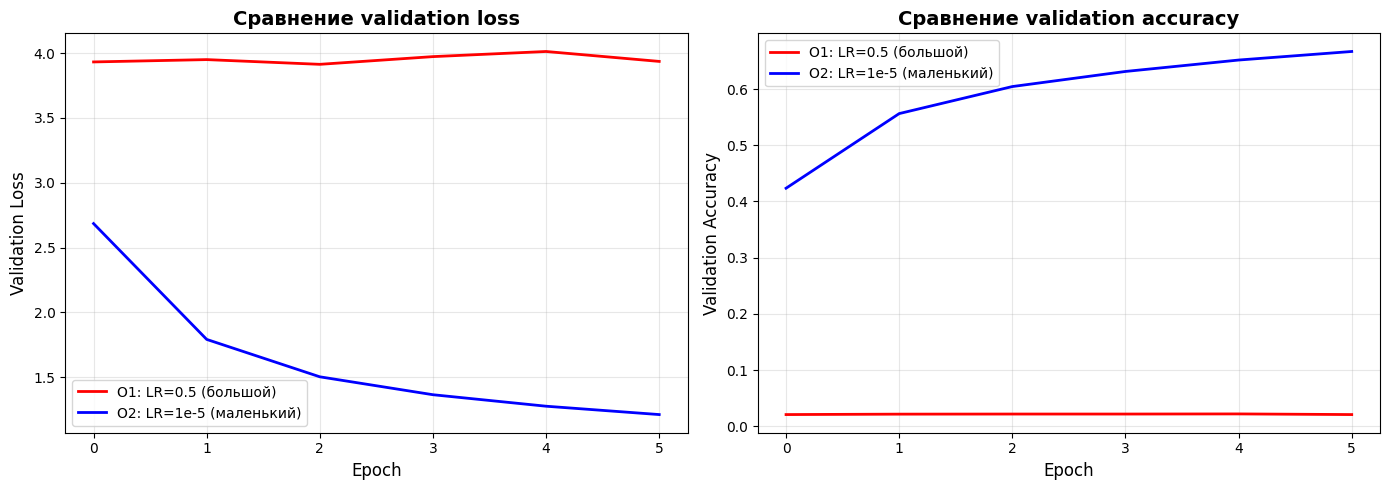

In [24]:
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_o1['val_loss'], 'r-', label='O1: LR=0.5 (большой)', linewidth=2)
axes[0].plot(history_o2['val_loss'], 'b-', label='O2: LR=1e-5 (маленький)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].set_title('Сравнение validation loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_o1['val_acc'], 'r-', label='O1: LR=0.5 (большой)', linewidth=2)
axes[1].plot(history_o2['val_acc'], 'b-', label='O2: LR=1e-5 (маленький)', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Сравнение validation accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
def get_best_metrics(hist):
    best_acc = max(hist['val_acc'])
    best_acc_idx = hist['val_acc'].index(best_acc)
    best_loss_at_best_acc = hist['val_loss'][best_acc_idx]
    
    return best_acc, best_loss_at_best_acc, len(hist['val_acc'])

# Сбор данных по экспериментам
runs_data = []

# E1: Base
acc, loss, epochs = get_best_metrics(e1_hist)
runs_data.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# E2: Dropout
acc, loss, epochs = get_best_metrics(e2_hist)
runs_data.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.3, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# E3: Base
acc, loss, epochs = get_best_metrics(e3_hist)
runs_data.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False', # Или bn=True если реализовано
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# E4: EarlyStopping
acc, loss, epochs = get_best_metrics(e4_hist)
runs_data.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False, early_stop(pat=5)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': early_stopper.best_score,
    'best_val_loss': min(e4_hist['val_loss'])
})

# O1: LR слишком большой
acc, loss, epochs = get_best_metrics(history_o1)
runs_data.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 5e-1,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

# O2: LR слишком маленький
acc, loss, epochs = get_best_metrics(history_o2)
runs_data.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0.0,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})


# O3: SGD + Momentum + Weight Decay
acc, loss, epochs = get_best_metrics(history_o3)
runs_data.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': SEED,
    'model_summary': 'hidden=[512,256,128], act=relu, dropout=0.0, bn=False',
    'optimizer': 'SGD',
    'lr': 2e-3,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': epochs,
    'best_val_accuracy': acc,
    'best_val_loss': loss
})

df_runs = pd.DataFrame(runs_data)

df_runs.to_csv('artifacts/runs.csv', index=False)